<a href="https://www.kaggle.com/code/lalit7881/python-osv-cvss-insights?scriptVersionId=305741715" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import networkx as nx
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/OSV_Vulnerability_Map.csv
/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/Open_Source_Edges.csv
/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/Open_Source_Nodes.csv


## Loading dataset

In [2]:
import pandas as pd

# Load datasets
df_nodes = pd.read_csv("/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/Open_Source_Nodes.csv")
df_edges = pd.read_csv("/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/Open_Source_Edges.csv")
df_vuln = pd.read_csv("/kaggle/input/datasets/kanchana1990/open-source-cyber-debt-the-contagion-graph/OSV_Vulnerability_Map.csv")

# ================================
# DATA QUALITY AUDIT
# ================================

print('='*70)
print('DATA QUALITY AUDIT — OSV_Vulnerability_Map')
print('='*70)

# Head
print(df_vuln.head(3).to_string())

# Missing values
print(f'\nMissing per column:')
print(df_vuln.isnull().sum())

# Duplicates
print(f'\nDuplicates: {df_vuln.duplicated().sum()}')

# Target distribution
print(f'\nTarget (Threat_Category) distribution:')
if 'Threat_Category' in df_vuln.columns:
    print(df_vuln['Threat_Category'].value_counts())
else:
    print("⚠️ 'Threat_Category' column not found. Available columns:")
    print(df_vuln.columns)

# ================================
# NODES DATA
# ================================

print('\n' + '='*70)
print('NODES DATA PREVIEW')
print('='*70)

print('\n── Nodes head ──')
print(df_nodes.head(5).to_string())

print('\nNodes shape:', df_nodes.shape)
print('\nNodes missing values:')
print(df_nodes.isnull().sum())

# ================================
# EDGES DATA
# ================================

print('\n' + '='*70)
print('EDGES DATA PREVIEW')
print('='*70)

print('\n── Edges head ──')
print(df_edges.head(5).to_string())

print('\nEdges shape:', df_edges.shape)
print('\nEdges missing values:')
print(df_edges.isnull().sum())

DATA QUALITY AUDIT — OSV_Vulnerability_Map
     Package     Vulnerability_ID                                                          CVSS_Vector                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Summary Attack_Vector Attack_Complexity Privileges_Required      Threat_Category  Summary_Length
0   invokeai  GHSA-227r-w

In [3]:
# ── Clean OSV Vuln dataframe ──────────────────────────────────────────────
df = df_vuln.copy()

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# -------------------------------
# Remove duplicates
# -------------------------------
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dupes removed: {before - len(df)}')

# -------------------------------
# Handle special string values
# -------------------------------
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].replace(['Unknown', 'unknown'], np.nan)
    df[c] = df[c].replace('None Required', 'None')

# -------------------------------
# Handle missing categorical
# -------------------------------
for c in df.select_dtypes(include='object').columns:
    if df[c].isnull().any():
        mode_val = df[c].mode(dropna=True)
        if len(mode_val) > 0:
            df[c] = df[c].fillna(mode_val[0])
        else:
            df[c] = df[c].fillna("Missing")

# -------------------------------
# Handle missing numeric
# -------------------------------
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

# -------------------------------
# Final check
# -------------------------------
assert df.isnull().sum().sum() == 0, '❌ Missing values remain!'

print(f'\n✅ Clean shape: {df.shape}  |  NaN: 0')

# -------------------------------
# Safe column checks (avoid crash)
# -------------------------------
if 'package' in df.columns:
    print(f'Unique packages   : {df["package"].nunique():,}')

if 'vulnerability_id' in df.columns:
    print(f'Unique vuln IDs   : {df["vulnerability_id"].nunique():,}')

if 'threat_category' in df.columns:
    print(f'Threat categories : {df["threat_category"].nunique()}')
    print(df['threat_category'].value_counts())
else:
    print("⚠️ 'threat_category' column not found!")
    print("Available columns:", df.columns)

Dupes removed: 6

✅ Clean shape: (19882, 9)  |  NaN: 0
Unique packages   : 12,300
Unique vuln IDs   : 18,566
Threat categories : 6
threat_category
Other / Unspecified            16084
Denial of Service (DoS)         1346
Remote Code Execution (RCE)      817
Auth Bypass                      701
Cross-Site Scripting (XSS)       600
Injection                        334
Name: count, dtype: int64


## EDA

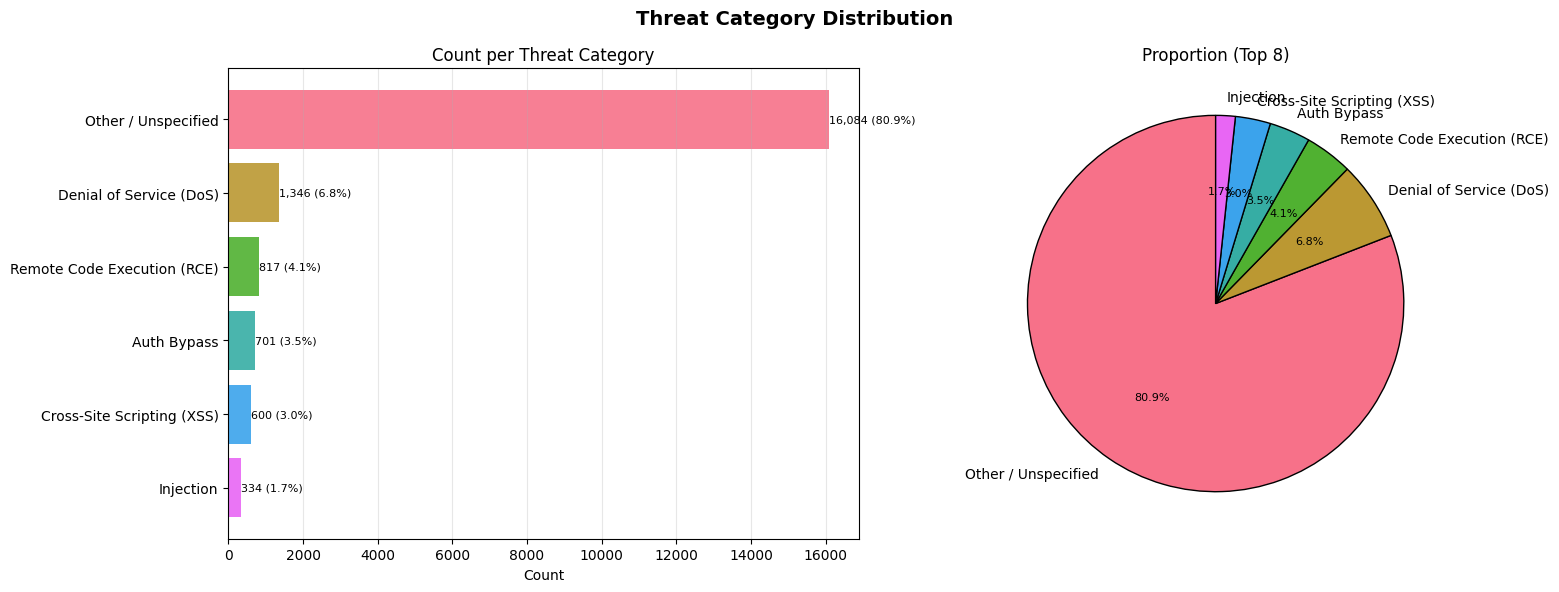

In [4]:
threat_counts = df['threat_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Threat Category Distribution', fontsize=14, fontweight='bold')

# Use vibrant palette
colors = sns.color_palette("husl", len(threat_counts))

# Bar chart
axes[0].barh(threat_counts.index, threat_counts.values, color=colors, alpha=0.9)

for i, v in enumerate(threat_counts.values):
    axes[0].text(v + 5, i, f'{v:,} ({100*v/len(df):.1f}%)', va='center', fontsize=8)

axes[0].set_xlabel('Count')
axes[0].set_title('Count per Threat Category')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    threat_counts.values[:8],
    labels=threat_counts.index[:8],
    colors=colors[:8],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

for t in autotexts:
    t.set_fontsize(8)

axes[1].set_title('Proportion (Top 8)')

plt.tight_layout()
plt.show()

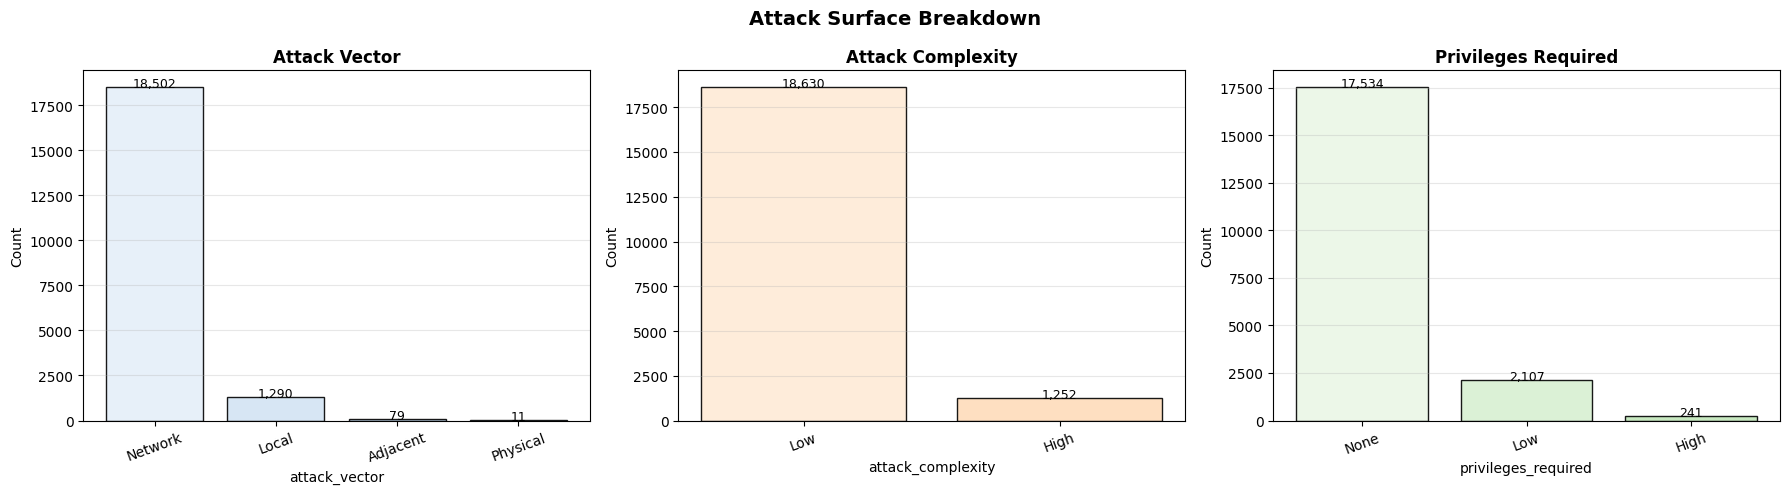

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Attack Surface Breakdown', fontsize=14, fontweight='bold')

# Different palettes for each column
palettes = [
    sns.color_palette("Blues", 10),     # Attack Vector
    sns.color_palette("Oranges", 10),   # Attack Complexity
    sns.color_palette("Greens", 10)     # Privileges Required
]

for ax, col, title, pal in zip(
    axes,
    ['attack_vector', 'attack_complexity', 'privileges_required'],
    ['Attack Vector', 'Attack Complexity', 'Privileges Required'],
    palettes
):
    vc = df[col].value_counts()

    ax.bar(vc.index, vc.values, color=pal[:len(vc)], alpha=0.9, edgecolor='black')

    for i, v in enumerate(vc.values):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=9)

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
top_pkgs = df['package'].value_counts().head(20)

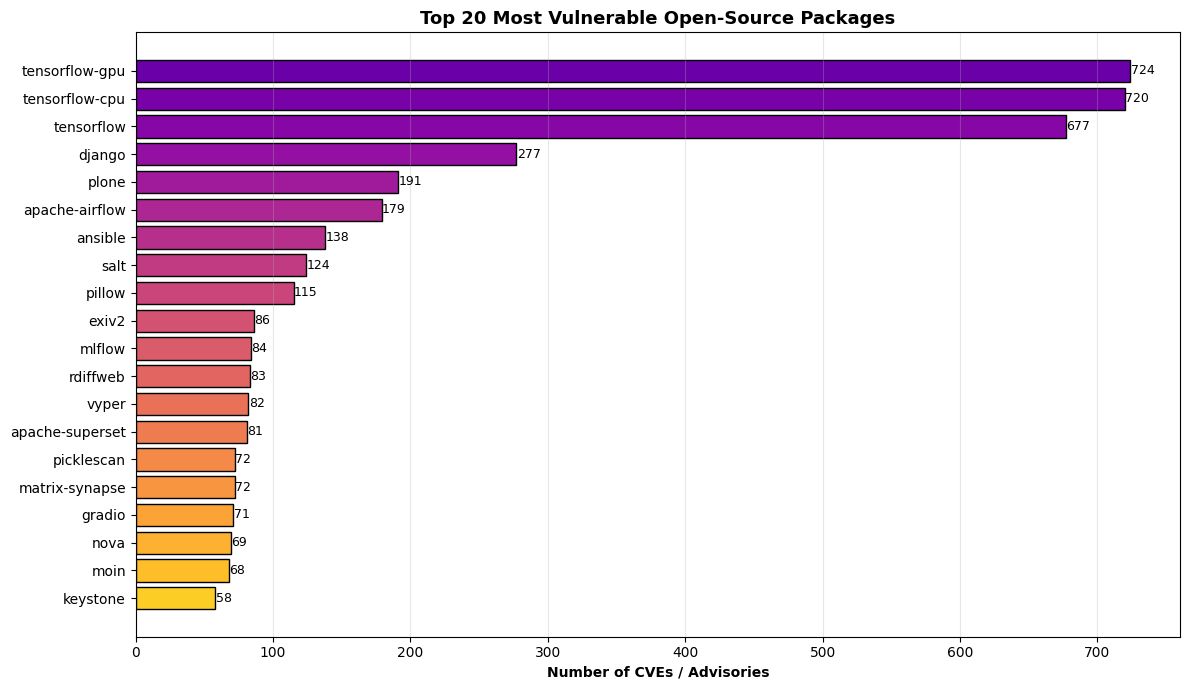

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

# Smooth gradient (dark → light)
colors = plt.cm.plasma(np.linspace(0.2, 0.9, 20))

ax.barh(range(20), top_pkgs.values, color=colors, edgecolor='black')
ax.set_yticks(range(20))
ax.set_yticklabels(top_pkgs.index)
ax.invert_yaxis()

for i, v in enumerate(top_pkgs.values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)

ax.set_xlabel('Number of CVEs / Advisories', fontweight='bold')
ax.set_title('Top 20 Most Vulnerable Open-Source Packages', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

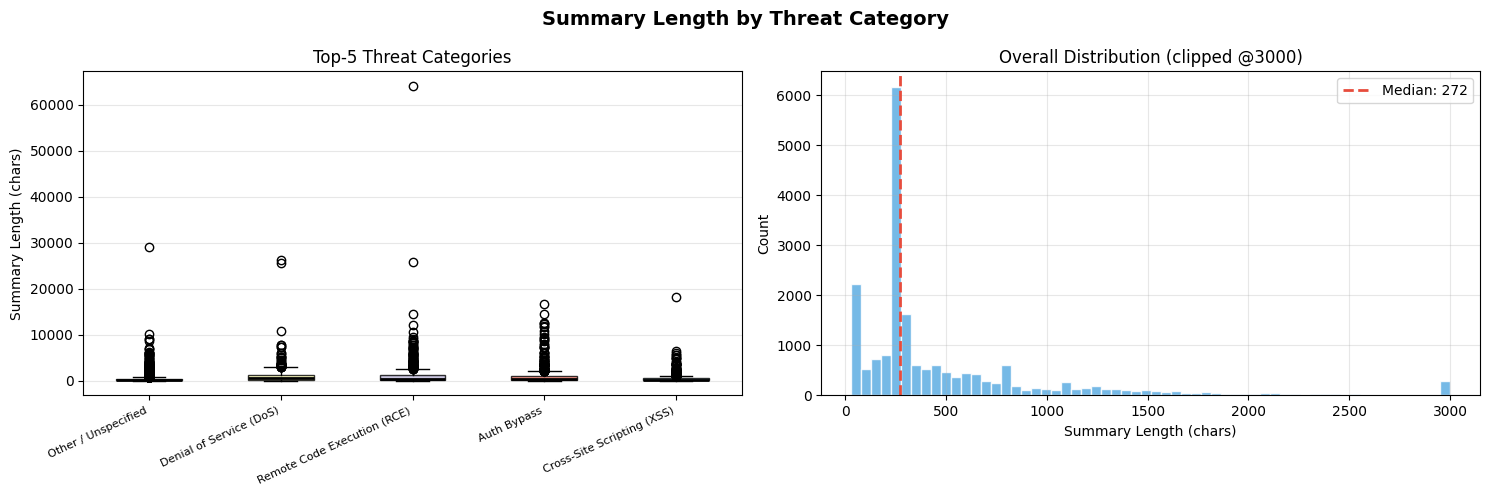

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Summary Length by Threat Category', fontsize=14, fontweight='bold')

# ✅ Define top categories
top5 = df['threat_category'].value_counts().head(5).index

# ✅ Create data for boxplot
data_box = [
    df[df['threat_category'] == c]['summary_length'].values
    for c in top5
]

# 🎨 Boxplot
pal5 = sns.color_palette("Set3", 5)

bp = axes[0].boxplot(
    data_box,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], pal5):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[0].set_xticklabels(top5, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Summary Length (chars)')
axes[0].set_title('Top-5 Threat Categories')
axes[0].grid(axis='y', alpha=0.3)

# 🎨 Histogram
axes[1].hist(
    df['summary_length'].clip(upper=3000),
    bins=60,
    color='#5DADE2',
    alpha=0.85,
    edgecolor='white'
)

axes[1].axvline(
    df['summary_length'].median(),
    color='#E74C3C',
    linestyle='--',
    linewidth=2,
    label=f'Median: {df["summary_length"].median():.0f}'
)

axes[1].set_xlabel('Summary Length (chars)')
axes[1].set_ylabel('Count')
axes[1].set_title('Overall Distribution (clipped @3000)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

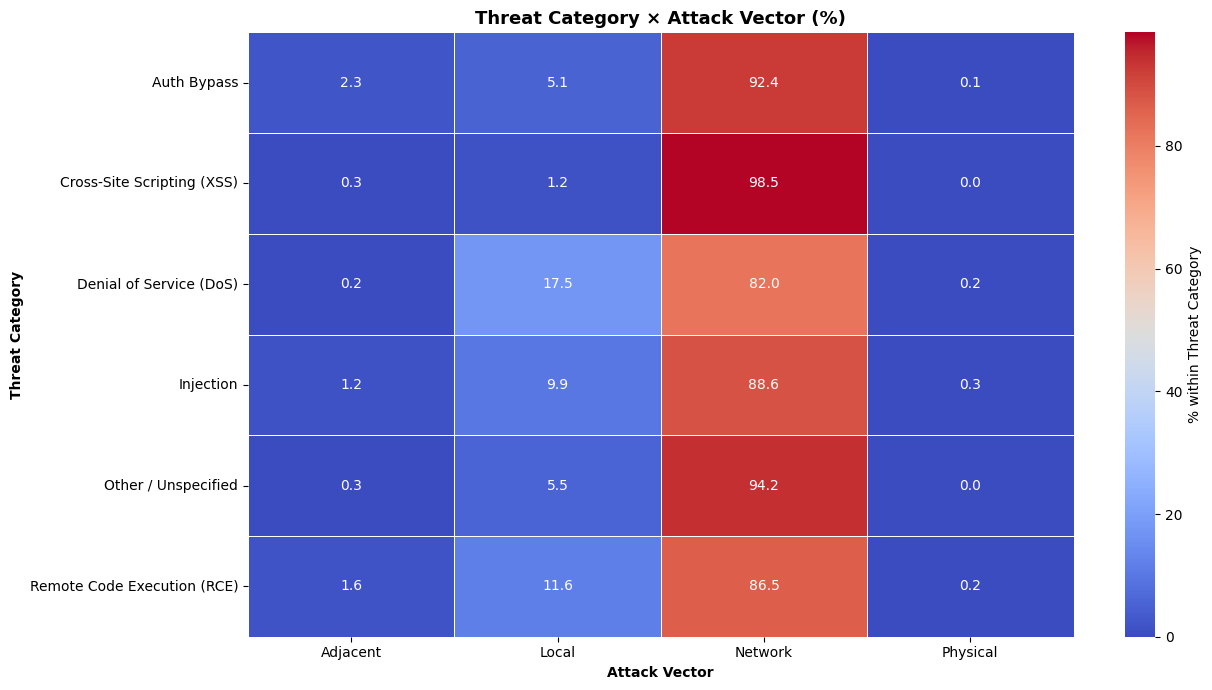

In [9]:
# ✅ Create pivot table
pivot = pd.crosstab(df['threat_category'], df['attack_vector'])

# ✅ Normalize to percentage
pivot_n = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 🎨 Heatmap
fig, ax = plt.subplots(figsize=(13, 7))

sns.heatmap(
    pivot_n,
    annot=True,
    fmt='.1f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'label': '% within Threat Category'},
    ax=ax
)

ax.set_title('Threat Category × Attack Vector (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Attack Vector', fontweight='bold')
ax.set_ylabel('Threat Category', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Clean column names
df_n = df_nodes.copy()
df_n.columns = df_n.columns.str.strip().str.lower().str.replace(' ', '_')

df_e = df_edges.copy()
df_e.columns = df_e.columns.str.strip().str.lower()

In [11]:
# Remove dependency-only rows if present
df_named = df_n[df_n['version'] != 'Dependency'].copy()

# Convert vulnerabilities to numeric
df_named['known_vulnerabilities'] = pd.to_numeric(
    df_named['known_vulnerabilities'],
    errors='coerce'
).fillna(0)

In [12]:
# Out-degree (dependencies count)
out_deg = df_e['source'].value_counts().reset_index()
out_deg.columns = ['package', 'out_degree']

# In-degree (dependents count)
in_deg = df_e['target'].apply(
    lambda x: x.split('>=')[0].split('<=')[0].split('==')[0]
              .split('!=')[0].split('<')[0].split('>')[0].strip()
)

in_deg = in_deg.value_counts().reset_index()
in_deg.columns = ['package', 'in_degree']

In [13]:
df_graph = df_named.merge(out_deg, on='package', how='left')
df_graph = df_graph.merge(in_deg, on='package', how='left')

df_graph['out_degree'] = df_graph['out_degree'].fillna(0).astype(int)
df_graph['in_degree'] = df_graph['in_degree'].fillna(0).astype(int)

# Risk score
df_graph['risk_score'] = df_graph['known_vulnerabilities'] * (1 + df_graph['in_degree'])

print("✅ df_graph created:", df_graph.shape)

✅ df_graph created: (20, 7)


In [14]:
plot_df = df_graph[df_graph['known_vulnerabilities'] > 0] \
    .sort_values('known_vulnerabilities', ascending=False) \
    .head(15)

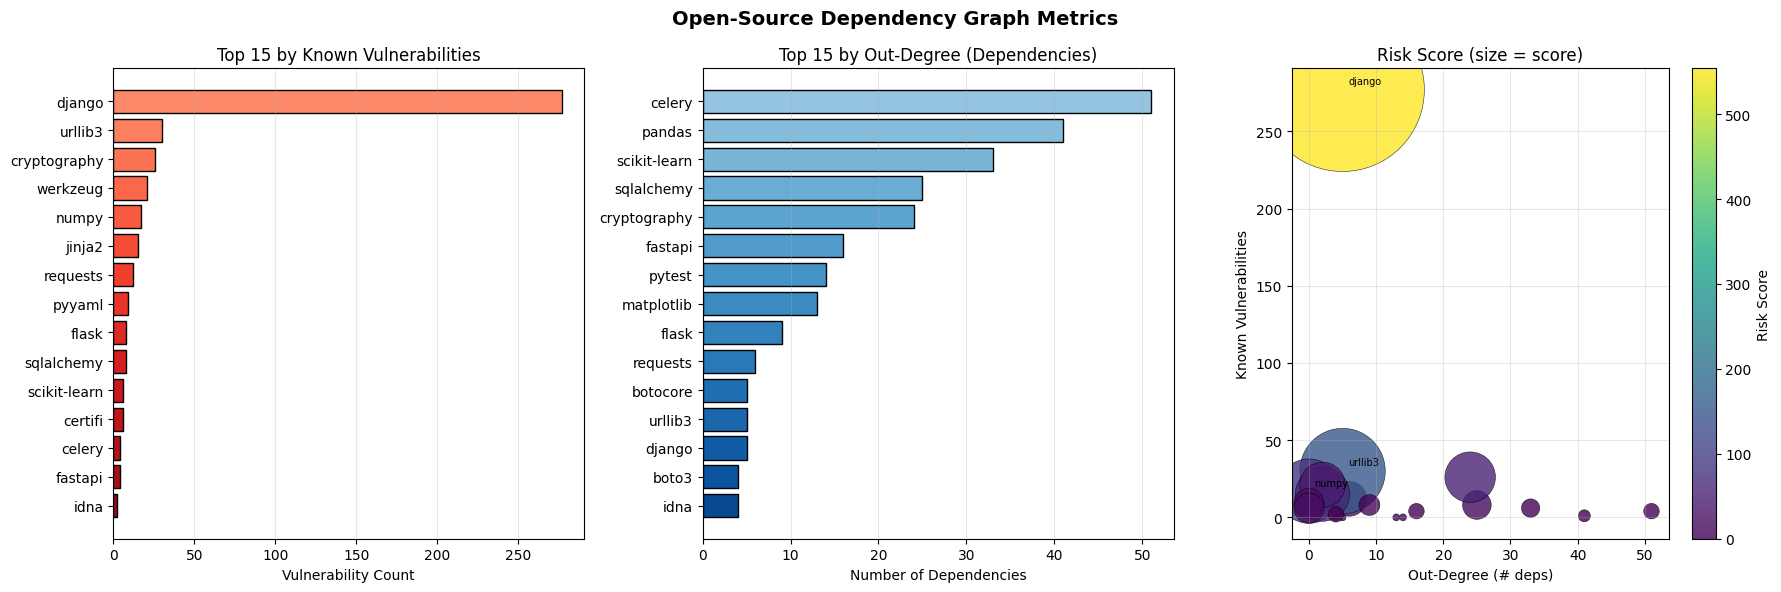

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Prepare datasets FIRST

# Top 15 by vulnerabilities
plot_df = df_graph[df_graph['known_vulnerabilities'] > 0] \
    .sort_values('known_vulnerabilities', ascending=False) \
    .head(15)

# Top 15 by out-degree
plot_df2 = df_graph.sort_values('out_degree', ascending=False).head(15)

# -------------------------------
# 🎨 Plotting
# -------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Open-Source Dependency Graph Metrics', fontsize=14, fontweight='bold')

# 1️⃣ Vulnerabilities (Red gradient)
col1 = plt.cm.Reds(np.linspace(0.4, 0.9, len(plot_df)))

axes[0].barh(
    plot_df['package'],
    plot_df['known_vulnerabilities'],
    color=col1,
    edgecolor='black'
)

axes[0].invert_yaxis()
axes[0].set_title('Top 15 by Known Vulnerabilities')
axes[0].set_xlabel('Vulnerability Count')
axes[0].grid(axis='x', alpha=0.3)

# 2️⃣ Dependencies (Blue gradient)
col2 = plt.cm.Blues(np.linspace(0.4, 0.9, len(plot_df2)))

axes[1].barh(
    plot_df2['package'],
    plot_df2['out_degree'],
    color=col2,
    edgecolor='black'
)

axes[1].invert_yaxis()
axes[1].set_title('Top 15 by Out-Degree (Dependencies)')
axes[1].set_xlabel('Number of Dependencies')
axes[1].grid(axis='x', alpha=0.3)

# 3️⃣ Risk Score Bubble
sc = axes[2].scatter(
    df_graph['out_degree'],
    df_graph['known_vulnerabilities'],
    s=(df_graph['risk_score'] + 1) * 25,
    c=df_graph['risk_score'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='black',
    linewidth=0.4
)

# Highlight top risky packages
top_risk = df_graph[df_graph['risk_score'] > df_graph['risk_score'].quantile(0.85)]

for _, row in top_risk.iterrows():
    axes[2].annotate(
        row['package'],
        (row['out_degree'], row['known_vulnerabilities']),
        fontsize=7,
        xytext=(4, 4),
        textcoords='offset points'
    )

plt.colorbar(sc, ax=axes[2], label='Risk Score')

axes[2].set_xlabel('Out-Degree (# deps)')
axes[2].set_ylabel('Known Vulnerabilities')
axes[2].set_title('Risk Score (size = score)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
# 🎯 Target column
TARGET = 'threat_category'

# -------------------------------
# Encode target
# -------------------------------
le_target = LabelEncoder()
y_raw = le_target.fit_transform(df[TARGET].astype(str))

TARGET_NAMES = le_target.classes_.tolist()
n_classes = len(TARGET_NAMES)

print(f'Classes ({n_classes}):')
for i, c in enumerate(TARGET_NAMES):
    print(f'  {i}: {c}  ({(y_raw==i).sum():,} = {100*(y_raw==i).sum()/len(y_raw):.1f}%)')

# -------------------------------
# Select numeric feature columns
# -------------------------------
DROP_COLS = [
    'threat_category', 'package', 'vulnerability_id',
    'cvss_vector', 'summary',
    'attack_vector', 'attack_complexity', 'privileges_required'
]

feature_cols = [
    c for c in df.columns
    if c not in DROP_COLS and df[c].dtype in [np.number, 'bool']
]

print(f'\nFeature columns ({len(feature_cols)}):')
for fc in feature_cols:
    print(f'  {fc}')

# -------------------------------
# Final X and y
# -------------------------------
X = df[feature_cols]
y = y_raw

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Classes (6):
  0: Auth Bypass  (701 = 3.5%)
  1: Cross-Site Scripting (XSS)  (600 = 3.0%)
  2: Denial of Service (DoS)  (1,346 = 6.8%)
  3: Injection  (334 = 1.7%)
  4: Other / Unspecified  (16,084 = 80.9%)
  5: Remote Code Execution (RCE)  (817 = 4.1%)

Feature columns (0):

X shape: (19882, 0)
y shape: (19882,)


In [18]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode important categorical columns
cat_cols = ['attack_vector', 'attack_complexity', 'privileges_required']

for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Target
y = LabelEncoder().fit_transform(df_model['threat_category'])

# Features
X = df_model.drop(columns=['threat_category', 'summary', 'cvss_vector'], errors='ignore')

print("X shape:", X.shape)

X shape: (19882, 6)


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

Classes: ['Auth Bypass', 'Cross-Site Scripting (XSS)', 'Denial of Service (DoS)', 'Injection', 'Other / Unspecified', 'Remote Code Execution (RCE)']
Feature shape: (19882, 31709)

✅ Accuracy: 0.8498868493839578

📋 Classification Report:

                             precision    recall  f1-score   support

                Auth Bypass       0.53      0.15      0.23       140
 Cross-Site Scripting (XSS)       0.77      0.57      0.66       120
    Denial of Service (DoS)       0.69      0.41      0.51       269
                  Injection       0.40      0.06      0.10        67
        Other / Unspecified       0.87      0.97      0.92      3217
Remote Code Execution (RCE)       0.59      0.29      0.39       164

                   accuracy                           0.85      3977
                  macro avg       0.64      0.41      0.47      3977
               weighted avg       0.82      0.85      0.82      3977


🎯 ROC-AUC: 0.9221846924166209

🔥 Top Features:
                     

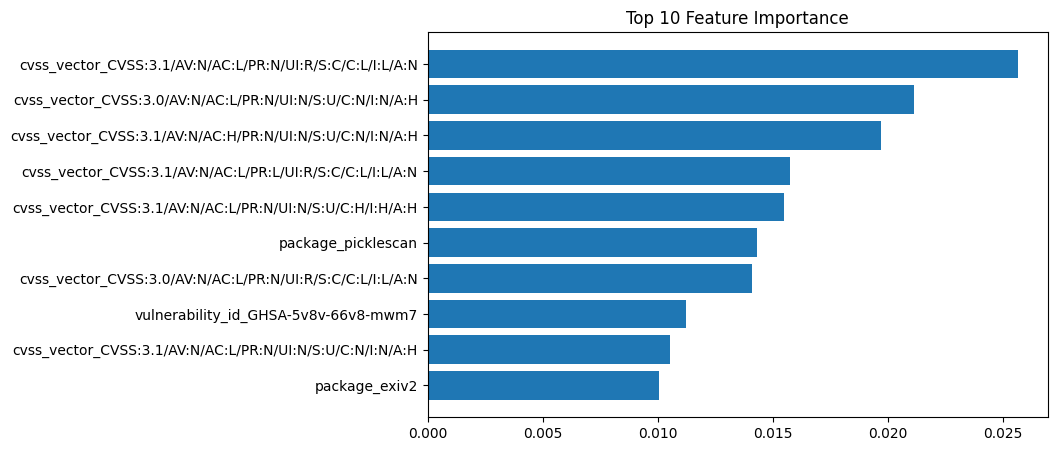

In [20]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna("unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

# ================================
# 🎯 4. Target Encoding
# ================================
TARGET = 'threat_category'

le = LabelEncoder()
y = le.fit_transform(df[TARGET].astype(str))

print("Classes:", list(le.classes_))

# ================================
# 🔧 5. Feature Engineering
# ================================

# Drop unnecessary columns
drop_cols = ['threat_category', 'summary']  # summary is large text
X = df.drop(columns=drop_cols, errors='ignore')

# Convert all categorical → numeric
X = pd.get_dummies(X, drop_first=True)

print("Feature shape:", X.shape)

# ================================
# ✂️ 6. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# ⚙️ 7. Scaling
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ================================
# 🤖 8. Model Training (XGBoost)
# ================================
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# 📊 9. Prediction
# ================================
y_pred = model.predict(X_test)

# ================================
# 📈 10. Evaluation
# ================================
acc = accuracy_score(y_test, y_pred)

print("\n✅ Accuracy:", acc)
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ================================
# 📉 11. ROC-AUC (Multi-class)
# ================================
try:
    y_prob = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print("\n🎯 ROC-AUC:", auc)
except:
    print("\nROC-AUC not available")

# ================================
# 🌟 12. Feature Importance
# ================================
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\n🔥 Top Features:")
print(feat_imp.head(10))

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp['feature'].head(10), feat_imp['importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

## Thank you..pls upvote!!!!!!!